## Import Required Libraries

In [1]:
# Add the project root to Python path so we can import pyTT
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from pathlib import Path
import lovely_tensors as lt
from PIL import Image
import glob
import re
from tqdm.auto import tqdm
import torch

# Import video compression utilities
from sdate.stream_hvec import HevcGray10Streamer, concat_hevc_segments

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")
print("✅ Video streaming compression utilities loaded:")
print("   - HevcGray10Streamer")
print("   - concat_hevc_segments")

Libraries imported successfully!
✅ Video streaming compression utilities loaded:
   - HevcGray10Streamer
   - concat_hevc_segments


## Load and Explore TIFF File Sequence

This section loads a sequence of TIFF files from a folder and assembles them into a video tensor.
Each TIFF file represents one frame of the video sequence.

In [3]:
# Define the path to the TIFF sequence folder
# Example paths - adjust to your actual data location:
# data_path = Path('../data/tiff_sequence/')  

# data_path = Path('/path/to/your/tiff/folder/')  
# data_path = Path('/das/home/barbaf_l/p22274/compression_paper/file_3_extracted')  
data_path = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')

# Check if the folder exists
if not data_path.exists():
    print(f"Error: Folder {data_path} does not exist!")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Looking for folder at: {data_path.absolute()}")
else:
    print(f"Folder found: {data_path.absolute()}")
    
    # List all TIFF files in the directory
    tiff_files = sorted(list(data_path.glob('*.tif')) + list(data_path.glob('*.tiff')))
    print(f"Found {len(tiff_files)} TIFF files")
    
    if len(tiff_files) > 0:
        print(f"First few files: {[f.name for f in tiff_files[:5]]}")
        print(f"Last few files: {[f.name for f in tiff_files[-5:]]}")
        
        # Analyze file naming pattern
        first_file = tiff_files[0].name
        print(f"\nAnalyzing file naming pattern from: {first_file}")
        
        # Try to extract naming pattern (e.g., PD1511_41_0001.tif)
        match = re.search(r'(.+?)_(\d+)\.(tiff?)', first_file)
        if match:
            prefix = match.group(1)
            print(f"Detected prefix pattern: '{prefix}_XXXX'")
        else:
            print("Could not detect standard naming pattern")
    else:
        print("❌ No TIFF files found in the directory")

Folder found: /myhome/data/sdate/shared/compression_paper/file_1_extracted
Found 1711 TIFF files
First few files: ['JC_62d0001.tif', 'JC_62d0002.tif', 'JC_62d0003.tif', 'JC_62d0004.tif', 'JC_62d0005.tif']
Last few files: ['JC_62d1707.tif', 'JC_62d1708.tif', 'JC_62d1709.tif', 'JC_62d1710.tif', 'JC_62d1711.tif']

Analyzing file naming pattern from: JC_62d0001.tif
Could not detect standard naming pattern


In [4]:
# Streaming TIFF processing functions for large sequences
import tifffile
import glob
from typing import Dict, Tuple

def load_tomography_params(data_folder: str) -> Dict[str, float]:
    """
    Load tomography parameters from log file or estimate from TIFF files.
    
    Parameters:
    -----------
    data_folder : str
        Path to folder containing TIFF files and possibly log files
        
    Returns:
    --------
    params : dict
        Dictionary containing num_darks, num_flats, num_projections
    """
    data_path = Path(data_folder)
    
    # Look for common log file patterns
    log_patterns = ['*.log', '*.txt', '*param*', '*config*']
    log_files = []
    for pattern in log_patterns:
        log_files.extend(list(data_path.glob(pattern)))
    
    params = {}
    
    # Try to read from log file first
    for log_file in log_files:
        try:
            with open(log_file, 'r') as f:
                content = f.read()
                
            # Look for common parameter names
            import re
            
            # Try different patterns
            patterns = {
                'num_darks': [r'num_darks\s*[=:]\s*(\d+)', r'dark.*?(\d+)', r'(\d+).*?dark'],
                'num_flats': [r'num_flats\s*[=:]\s*(\d+)', r'flat.*?(\d+)', r'(\d+).*?flat'],
                'num_projections': [r'num_projections\s*[=:]\s*(\d+)', r'proj.*?(\d+)', r'(\d+).*?proj']
            }
            
            for param_name, pattern_list in patterns.items():
                for pattern in pattern_list:
                    match = re.search(pattern, content, re.IGNORECASE)
                    if match:
                        params[param_name] = int(match.group(1))
                        break
                if param_name in params:
                    continue
                    
            if len(params) == 3:
                print(f"✅ Found parameters in {log_file.name}: {params}")
                return params
                
        except Exception as e:
            continue
    
    # If no log file found or parameters not extracted, use manual input or defaults
    print("⚠️  Could not find/parse log file with tomography parameters")
    print("Please provide the number of darks, flats, and projections:")
    
    # For now, return default values - user should modify these
    tiff_files = sorted(list(data_path.glob('*.tif*')))
    total_files = len(tiff_files)
    
    # Common defaults for tomography scans
    params = {
        'num_darks': 10,        # Typical number of dark images
        'num_flats': 10,        # Typical number of flat images  
        'num_projections': total_files - 20  # Remaining files are projections
    }
    
    print(f"🔧 Using default parameters: {params}")
    print(f"   Total TIFF files: {total_files}")
    
    return params


def estimate_tiff_dynamic_range_tomography(tiff_files, params=None, sample_ratio=0.1, min_samples=20, max_samples=200, 
                                          create_histogram=True, hist_bins=256, max_pixels_for_hist=1000000, hist_offset=0,
                                          use_attenuation_correction=False, epsilon=1e-6):
    """
    Estimate global min/max values by sampling projections only from tomographic data.
    
    Args:
        tiff_files: List of Path objects pointing to TIFF files
        params: Dictionary with 'num_darks', 'num_flats', 'num_projections' or None to auto-detect
        sample_ratio: Fraction of projection files to sample (0.1 = 10%)
        min_samples: Minimum number of files to sample
        max_samples: Maximum number of files to sample
        create_histogram: Whether to create histogram visualization
        hist_bins: Number of bins for histogram
        max_pixels_for_hist: Maximum number of pixels to use for histogram (to control memory)
        hist_offset: Offset frames to start collecting stats within projections
        use_attenuation_correction: If True, compute range on attenuation-corrected values using darks/flats
        epsilon: Small value to avoid log(0) when using attenuation correction
    
    Returns:
        tuple: (global_min, global_max, height, width, dtype_info, params_used)
    """
    print(f"🔍 Estimating dynamic range from tomographic TIFF sequence...")
    print(f"   Total TIFF files: {len(tiff_files)}")
    print(f"   Mode: {'Attenuation-corrected values' if use_attenuation_correction else 'Raw pixel values'}")
    
    # Get tomography parameters
    if params is None:
        data_folder = tiff_files[0].parent
        params = load_tomography_params(data_folder)
    
    # Extract counts from parameters
    num_darks = int(params['num_darks'])
    num_flats = int(params['num_flats'])
    num_projections = int(params['num_projections'])
    
    expected_total = num_darks + num_flats + num_projections
    if len(tiff_files) != expected_total:
        print(f"⚠️  Warning: Found {len(tiff_files)} files, expected {expected_total}")
        print(f"   Expected: {num_darks} darks + {num_flats} flats + {num_projections} projections")
        
        # Adjust if needed
        actual_projections = len(tiff_files) - num_darks - num_flats
        if actual_projections > 0:
            num_projections = actual_projections
            params['num_projections'] = num_projections
            print(f"   Adjusted projections to: {num_projections}")
    
    print(f"📊 Tomographic sequence structure:")
    print(f"   Dark images: {num_darks} (files 1-{num_darks})")
    print(f"   Flat images: {num_flats} (files {num_darks+1}-{num_darks+num_flats})")
    print(f"   Projections: {num_projections} (files {num_darks+num_flats+1}-{len(tiff_files)})")
    
    # Load first file to get dimensions
    first_img = Image.open(tiff_files[0])
    first_array = np.array(first_img)
    height, width = first_array.shape[:2]
    
    print(f"   Image dimensions: {width} x {height}")
    print(f"   Original dtype: {first_array.dtype}")
    
    # Load darks and flats if using attenuation correction
    dark_avg = None
    flat_avg = None
    denominator = None
    
    if use_attenuation_correction:
        print(f"🔬 Loading darks and flats for attenuation correction...")
        
        # Load dark images
        dark_files = tiff_files[:num_darks]
        darks = []
        for dark_file in tqdm(dark_files, desc="Loading darks"):
            img = Image.open(dark_file)
            arr = np.array(img, dtype=np.float32)
            if arr.ndim == 3:
                arr = arr[:, :, 0]
            darks.append(arr)
        darks = np.array(darks)
        dark_avg = np.median(darks, axis=0)
        del darks  # Free memory
        print(f"   Dark average range: [{dark_avg.min():.2f}, {dark_avg.max():.2f}]")
        
        # Load flat images
        flat_files = tiff_files[num_darks:num_darks + num_flats]
        flats = []
        for flat_file in tqdm(flat_files, desc="Loading flats"):
            img = Image.open(flat_file)
            arr = np.array(img, dtype=np.float32)
            if arr.ndim == 3:
                arr = arr[:, :, 0]
            flats.append(arr)
        flats = np.array(flats)
        flat_avg = np.median(flats, axis=0)
        del flats  # Free memory
        print(f"   Flat average range: [{flat_avg.min():.2f}, {flat_avg.max():.2f}]")
        
        # Precompute denominator to avoid division by zero
        denominator = flat_avg - dark_avg
        denominator = np.where(denominator == 0, 1e-6, denominator)
        print(f"   Attenuation correction setup complete!")
    
    # Get projection files only (skip darks and flats)
    projection_start_idx = num_darks + num_flats
    projection_files = tiff_files[projection_start_idx:]
    
    print(f"🎯 Focusing on projection files for dynamic range estimation...")
    
    # Calculate number of samples from projections only
    num_samples = max(min_samples, min(max_samples, int(len(projection_files) * sample_ratio)))
    print(f"   Sampling {num_samples} projection files ({100*num_samples/len(projection_files):.1f}% of projections)")
    
    # Get sample indices distributed across the projection sequence
    sample_indices = np.linspace(0, len(projection_files)-1, num_samples, dtype=int)
    
    # Initialize min/max tracking and histogram data collection
    global_min = float('inf')
    global_max = float('-inf')
    
    # For histogram: accumulate histogram on-the-fly without storing all pixels
    histogram_counts = None
    histogram_bins_array = None
    pixels_counted = 0
    
    # Sample projection files to estimate range
    desc_text = "Estimating attenuation range" if use_attenuation_correction else "Estimating range from projections"
    for idx in tqdm(sample_indices, desc=desc_text):
        img = Image.open(projection_files[idx])
        arr = np.array(img, dtype=np.float32)
        
        # Handle different image formats
        if arr.ndim == 3:  # Color image
            arr = arr[:, :, 0]  # Take first channel
        
        # Apply attenuation correction if enabled
        if use_attenuation_correction:
            # Apply attenuation correction: -log((projection - dark) / (flat - dark) + epsilon)
            normalized = (arr - dark_avg) / denominator
            normalized = np.clip(normalized, 0, None)  # Clip negative values
            arr = -np.log(normalized + epsilon)
        
        # Update global min/max
        current_min = float(arr.min())
        current_max = float(arr.max())
        global_min = min(global_min, current_min)
        global_max = max(global_max, current_max)
        
        # Accumulate histogram on-the-fly (after first pass to know range)
        if idx > hist_offset and create_histogram:
            flat_arr = arr.flatten()
            
            # Initialize histogram on first pass after offset
            if histogram_counts is None:
                # Use the current range as initial estimate for bins
                hist_range = (current_min, current_max)
                histogram_bins_array = np.linspace(hist_range[0], hist_range[1], hist_bins + 1)
                histogram_counts = np.zeros(hist_bins, dtype=np.int64)
            
            # Compute histogram for this image and add to accumulator
            counts, _ = np.histogram(flat_arr, bins=histogram_bins_array)
            histogram_counts += counts
            pixels_counted += len(flat_arr)
    
    if use_attenuation_correction:
        print(f"   Estimated attenuation range: [{global_min:.4f}, {global_max:.4f}]")
    else:
        print(f"   Estimated projection range: [{global_min}, {global_max}]")
        # Since compression goes to 10-bits, it does not make sense to super resolute the range
        global_max = max(global_max, 2**10 - 1) 
    
    # Create histogram visualization
    if create_histogram and histogram_counts is not None:
        print(f"   Creating histogram from {pixels_counted:,} {'attenuation' if use_attenuation_correction else 'pixel'} values...")
        
        # Recompute bin edges with final global_min, global_max for better visualization
        final_bins = np.linspace(global_min, global_max, hist_bins + 1)
        bin_centers = (final_bins[:-1] + final_bins[1:]) / 2
        
        # Create the histogram plot
        plt.figure(figsize=(12, 8))
        
        # Main histogram
        plt.subplot(2, 1, 1)
        plt.bar(bin_centers, histogram_counts, width=(final_bins[1] - final_bins[0]), 
                alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
        value_type = "Attenuation" if use_attenuation_correction else "Pixel"
        plt.title(f'Projection {value_type} Value Distribution (Dynamic Range Analysis)\nSampled from {num_samples} projection files ({pixels_counted:,} values)', 
                  fontsize=14, fontweight='bold')
        plt.xlabel(f'{value_type} Value')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        # Calculate statistics from histogram bins
        total_counts = histogram_counts.sum()
        mean_val = np.sum(bin_centers * histogram_counts) / total_counts
        variance = np.sum(((bin_centers - mean_val) ** 2) * histogram_counts) / total_counts
        std_val = np.sqrt(variance)
        
        # Approximate median from histogram
        cumsum = np.cumsum(histogram_counts)
        median_idx = np.searchsorted(cumsum, total_counts / 2)
        median_val = bin_centers[median_idx] if median_idx < len(bin_centers) else bin_centers[-1]
        
        # Add vertical lines for statistics
        plt.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.1f}')
        plt.axvline(median_val, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_val:.1f}')
        plt.axvline(global_min, color='green', linestyle='-', alpha=0.8, label=f'Min: {global_min:.1f}')
        plt.axvline(global_max, color='purple', linestyle='-', alpha=0.8, label=f'Max: {global_max:.1f}')
        plt.legend()
        
        # Log-scale histogram for better visualization of distribution tails
        plt.subplot(2, 1, 2)
        plt.bar(bin_centers, histogram_counts, width=(final_bins[1] - final_bins[0]),
                alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
        plt.yscale('log')
        plt.title(f'Projection {value_type} Value Distribution (Log Scale)', fontsize=12, fontweight='bold')
        plt.xlabel(f'{value_type} Value')
        plt.ylabel('Frequency (Log Scale)')
        plt.grid(True, alpha=0.3)
        
        # Add the same statistics lines
        plt.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.1f}')
        plt.axvline(median_val, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_val:.1f}')
        plt.axvline(global_min, color='green', linestyle='-', alpha=0.8, label=f'Min: {global_min:.1f}')
        plt.axvline(global_max, color='purple', linestyle='-', alpha=0.8, label=f'Max: {global_max:.1f}')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed statistics
        print(f"\n📊 Projection {'Attenuation' if use_attenuation_correction else 'Histogram'} Statistics:")
        print(f"   Values analyzed: {pixels_counted:,}")
        print(f"   Mean: {mean_val:.4f}" if use_attenuation_correction else f"   Mean: {mean_val:.2f}")
        print(f"   Median: {median_val:.4f}" if use_attenuation_correction else f"   Median: {median_val:.2f}")
        print(f"   Std deviation: {std_val:.4f}" if use_attenuation_correction else f"   Std deviation: {std_val:.2f}")
        print(f"   Min: {global_min:.4f}" if use_attenuation_correction else f"   Min: {global_min:.1f}")
        print(f"   Max: {global_max:.4f}" if use_attenuation_correction else f"   Max: {global_max:.1f}")
        print(f"   Range: {global_max - global_min:.4f}" if use_attenuation_correction else f"   Range: {global_max - global_min:.1f}")
        
        # Percentile analysis from histogram
        percentiles = [1, 5, 10, 25, 75, 90, 95, 99]
        percentile_values = []
        for pct in percentiles:
            target_count = total_counts * pct / 100
            pct_idx = np.searchsorted(cumsum, target_count)
            pct_val = bin_centers[pct_idx] if pct_idx < len(bin_centers) else bin_centers[-1]
            percentile_values.append(pct_val)
        
        print(f"\n   Percentiles:")
        for pct, val in zip(percentiles, percentile_values):
            print(f"     {pct:2d}%: {val:.4f}" if use_attenuation_correction else f"     {pct:2d}%: {val:.1f}")
        

        # Dynamic range utilization (only meaningful for raw pixel values)
        if not use_attenuation_correction:
            theoretical_max = 2**16 - 1 if global_max <= 65535 else 2**32 - 1
            utilization = (global_max - global_min) / theoretical_max * 100
            print(f"\n   Dynamic range utilization: {utilization:.2f}%")
            print(f"   (Range used: {global_max - global_min:.0f} / Theoretical: {theoretical_max})")
    
    # Determine optimal data type
    dtype_info = {
        'original_dtype': first_array.dtype,
        'fits_16bit': global_max <= 65535 and global_min >= 0,
        'range': global_max - global_min
    }
    
    return global_min, global_max, height, width, dtype_info, params


def compute_attenuation_projections(projections: np.ndarray, darks: np.ndarray, flats: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    """
    Compute attenuation projections directly from raw projections without storing intermediate normalized projections.
    This is memory-efficient for large datasets.
    
    Formula: attenuation = -log((projection - dark_avg) / (flat_avg - dark_avg) + epsilon)
    
    Parameters:
    -----------
    projections : np.ndarray
        Raw projection images
    darks : np.ndarray
        Dark field images
    flats : np.ndarray
        Flat field images
    epsilon : float
        Small value to avoid log(0)
        
    Returns:
    --------
    attenuation_projections : np.ndarray
        Attenuation projection images
    """
    print("Computing average dark and flat images...")
    
    # Compute averages
    dark_avg = np.median(darks, axis=0)
    flat_avg = np.median(flats, axis=0)

    print(f"Dark average range: [{dark_avg.min():.2f}, {dark_avg.max():.2f}]")
    print(f"Flat average range: [{flat_avg.min():.2f}, {flat_avg.max():.2f}]")
    
    # Avoid division by zero
    denominator = flat_avg - dark_avg
    denominator = np.where(denominator == 0, 1e-6, denominator)
    
    print("Computing attenuation projections directly...")
    
    # Compute attenuation projections directly without storing normalized projections
    attenuation_projections = np.zeros_like(projections, dtype=np.float32)
    for i in range(len(projections)):
        # Normalize and immediately convert to attenuation
        normalized = (projections[i] - dark_avg) / denominator
        normalized = np.clip(normalized, 0, None)  # Clip negative values
        attenuation_projections[i] = -np.log(normalized + epsilon)
    
    print(f"Attenuation projections range: [{attenuation_projections.min():.4f}, {attenuation_projections.max():.4f}]")
    
    return attenuation_projections


def stream_tiff_projections_to_hevc(tiff_files, params, output_path, global_min, global_max, 
                                   start_offset=0, max_frames=None, 
                                   fps=30, quality=90, segment_prefix="projections",
                                   force_software=False, preset_sw="medium",
                                   use_attenuation_correction=False, epsilon=1e-6):
    """
    Stream projection TIFF files only to HEVC compression without loading all into memory.
    
    Args:
        tiff_files: List of Path objects pointing to TIFF files
        params: Dictionary with tomography structure info
        output_path: Output directory for compressed segments
        global_min, global_max: Pre-computed dynamic range for normalization (used when use_attenuation_correction=False)
        start_offset: Frame offset to start from within projections
        max_frames: Maximum number of projection frames to process (None for all)
        fps: Frames per second for the output video
        quality: Compression quality (0-100, higher = better quality)
        segment_prefix: Prefix for segment files
        force_software: Whether to force software encoding (True/False)
        preset_sw: Software encoding preset (e.g., "medium", "slow", "veryslow")
        use_attenuation_correction: If True, use darks/flats for attenuation correction; if False, use simple normalization
        epsilon: Small value to avoid log(0) when using attenuation correction
    
    Returns:
        tuple: (streamer, processed_frames, output_segments)
    """
    # Extract projection files only
    num_darks = int(params['num_darks'])
    num_flats = int(params['num_flats'])
    num_projections = int(params['num_projections'])
    
    # Load darks and flats if using attenuation correction
    dark_avg = None
    flat_avg = None
    denominator = None
    
    if use_attenuation_correction:
        print("🔬 Loading darks and flats for attenuation correction...")
        
        # Load dark images
        dark_files = tiff_files[:num_darks]
        darks = []
        for dark_file in tqdm(dark_files, desc="Loading darks"):
            img = Image.open(dark_file)
            arr = np.array(img, dtype=np.float32)
            if arr.ndim == 3:
                arr = arr[:, :, 0]
            darks.append(arr)
        darks = np.array(darks)
        dark_avg = np.median(darks, axis=0)
        print(f"   Dark average range: [{dark_avg.min():.2f}, {dark_avg.max():.2f}]")
        
        # Load flat images
        flat_files = tiff_files[num_darks:num_darks + num_flats]
        flats = []
        for flat_file in tqdm(flat_files, desc="Loading flats"):
            img = Image.open(flat_file)
            arr = np.array(img, dtype=np.float32)
            if arr.ndim == 3:
                arr = arr[:, :, 0]
            flats.append(arr)
        flats = np.array(flats)
        flat_avg = np.median(flats, axis=0)
        print(f"   Flat average range: [{flat_avg.min():.2f}, {flat_avg.max():.2f}]")
        
        # Precompute denominator to avoid division by zero
        denominator = flat_avg - dark_avg
        denominator = np.where(denominator == 0, 1e-6, denominator)
        print(f"   Attenuation correction setup complete!")
    
    projection_files = tiff_files[num_darks + num_flats:]
    
    print(f"🎬 Streaming compression of projection TIFF files...")
    print(f"   Total projections available: {len(projection_files)}")
    print(f"   Processing mode: {'Attenuation correction' if use_attenuation_correction else 'Simple normalization'}")
    
    # Determine which projection files to process
    if max_frames is not None:
        projection_files_to_process = projection_files[start_offset:start_offset+max_frames]
    else:
        projection_files_to_process = projection_files[start_offset:]
    
    print(f"   Processing {len(projection_files_to_process)} projection files...")
    print(f"   Output directory: {output_path}")
    if use_attenuation_correction:
        print(f"   Attenuation range: [{global_min}, {global_max}] (for normalization after log transform)")
        print(f"   Epsilon: {epsilon}")
    else:
        print(f"   Normalization range: [{global_min}, {global_max}]")
    print(f"   Quality: {quality}, FPS: {fps}")
    
    # Create output directory
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Initialize the HEVC streamer
    from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams
    
    # Configure encoder parameters
    encoder_params = EncoderParams(
        fps=fps,
        cq_hw=quality,  # Hardware quality
        crf_sw=min(51, 51 - int(quality * 51 / 100)),  # Software fallback
        preset_sw=preset_sw,  # Faster than veryslow for streaming
        force_software=force_software,  # Try hardware first
        threads=0  # Auto-detect
    )
    
    # Create streamer
    streamer = HevcGray10Streamer(
        base_path=output_path,
        segment_prefix=segment_prefix,
        params=encoder_params,
    )
    
    # Start the first segment
    segment_name = f"{segment_prefix}_projections.mov"
    processed_frames = 0
    
    try:
        with streamer.start_segment(q=quality, outfile=segment_name):
            print(f"   Started segment: {segment_name}")
            
            # Process each projection TIFF file
            desc_text = "Processing projection frames (attenuation)" if use_attenuation_correction else "Processing projection frames (normalization)"
            for i, tiff_file in enumerate(tqdm(projection_files_to_process, desc=desc_text)):
                # try:
                # Load and process the image
                img = Image.open(tiff_file)
                arr = np.array(img, dtype=np.float32)
                
                # Handle different image formats
                if arr.ndim == 3:  # Color image
                    arr = arr[:, :, 0]  # Take first channel
                
                if use_attenuation_correction:
                    # Apply attenuation correction: -log((projection - dark) / (flat - dark) + epsilon)
                    normalized = (arr - dark_avg) / denominator
                    normalized = np.clip(normalized, 0, None)  # Clip negative values
                    attenuation = -np.log(normalized + epsilon)
                    
                    # Normalize attenuation to [0, 1] for encoding
                    # Use global_min and global_max as the expected attenuation range
                    frame_tensor = torch.from_numpy(attenuation).float()
                    frame_tensor = (frame_tensor - global_min) / (global_max - global_min)
                    frame_tensor = torch.clamp(frame_tensor, 0.0, 1.0)
                else:
                    # Simple normalization to [0, 1] using pre-computed range
                    frame_tensor = torch.from_numpy(arr).float()
                    frame_tensor = (frame_tensor - global_min) / (global_max - global_min)
                    frame_tensor = torch.clamp(frame_tensor, 0.0, 1.0)
                
                # Append to streamer
                streamer.append_frame(frame_tensor)
                processed_frames += 1
                        
                # except Exception as e:
                #     print(f"   ⚠️  Error processing projection frame {i} ({tiff_file.name}): {e}")
                #     continue
        
        print(f"✅ Streaming compression of projections completed!")
        print(f"   Processed projection frames: {processed_frames}")
        print(f"   Output segments: {len(streamer.segments)}")
        
        return streamer, processed_frames, streamer.segments
        
    except Exception as e:
        print(f"❌ Error during streaming compression: {e}")
        # Make sure to close the streamer even if there's an error
        try:
            streamer.close_segment()
        except:
            pass
        raise


# Keep the original function for backward compatibility
def estimate_tiff_dynamic_range(tiff_files, sample_ratio=0.1, min_samples=20, max_samples=200, 
                               create_histogram=True, hist_bins=256, max_pixels_for_hist=1000000, hist_offset=0,
                               use_attenuation_correction=False, epsilon=1e-6):
    """
    Original function - now calls the tomography-aware version with auto-detection.
    """
    return estimate_tiff_dynamic_range_tomography(
        tiff_files, params=None, sample_ratio=sample_ratio, min_samples=min_samples, 
        max_samples=max_samples, create_histogram=create_histogram, hist_bins=hist_bins,
        max_pixels_for_hist=max_pixels_for_hist, hist_offset=hist_offset,
        use_attenuation_correction=use_attenuation_correction, epsilon=epsilon
    )


def stream_tiff_to_hevc(tiff_files, output_path, global_min, global_max, 
                       start_offset=0, max_frames=None, 
                       fps=30, quality=90, segment_prefix="segment"):
    """
    Original function - maintained for backward compatibility.
    This will process all TIFF files, not just projections.
    """
    # Determine which files to process
    if max_frames is not None:
        tiff_files_to_process = tiff_files[start_offset:start_offset+max_frames]
    else:
        tiff_files_to_process = tiff_files[start_offset:]
    
    print(f"🎬 Starting streaming compression of {len(tiff_files_to_process)} TIFF files...")
    print(f"   Output directory: {output_path}")
    print(f"   Normalization range: [{global_min}, {global_max}]")
    print(f"   Quality: {quality}, FPS: {fps}")
    
    # Create output directory
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Initialize the HEVC streamer
    from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams
    
    # Configure encoder parameters
    params = EncoderParams(
        fps=fps,
        cq_hw=quality,  # Hardware quality
        crf_sw=max(10, min(51, 51 - int(quality * 41 / 100))),  # Software fallback
        preset_sw="medium",  # Faster than veryslow for streaming
        force_software=False,  # Try hardware first
        threads=0  # Auto-detect
    )
    
    # Create streamer
    streamer = HevcGray10Streamer(
        base_path=output_path,
        segment_prefix=segment_prefix,
        params=params
    )
    
    # Start the first segment
    segment_name = f"{segment_prefix}_full.mov"
    processed_frames = 0
    
    try:
        with streamer.start_segment(q=quality, outfile=segment_name):
            print(f"   Started segment: {segment_name}")
            
            # Process each TIFF file
            for i, tiff_file in enumerate(tqdm(tiff_files_to_process, desc="Processing frames")):
                # try:
                # Load and process the image
                img = Image.open(tiff_file)
                arr = np.array(img, np.int32)
                
                # Handle different image formats
                if arr.ndim == 3:  # Color image
                    arr = arr[:, :, 0]  # Take first channel
                
                # Convert to float32 tensor and normalize to [0, 1]
                frame_tensor = torch.from_numpy(arr).float()
                frame_tensor = (frame_tensor - global_min) / (global_max - global_min)
                
                # Clamp to ensure [0, 1] range
                frame_tensor = torch.clamp(frame_tensor, 0.0, 1.0)
                
                # Append to streamer
                streamer.append_frame(frame_tensor)
                processed_frames += 1
                
                # Optional: Print progress every N frames
                if (i + 1) % 100 == 0:
                    print(f"   Processed {i + 1}/{len(tiff_files_to_process)} frames...")
                        
                # except Exception as e:
                #     print(f"   ⚠️  Error processing frame {i} ({tiff_file.name}): {e}")
                #     continue
        
        print(f"✅ Streaming compression completed!")
        print(f"   Processed frames: {processed_frames}")
        print(f"   Output segments: {len(streamer.segments)}")
        
        return streamer, processed_frames, streamer.segments
        
    except Exception as e:
        print(f"❌ Error during streaming compression: {e}")
        # Make sure to close the streamer even if there's an error
        try:
            streamer.close_segment()
        except:
            pass
        raise


def get_compressed_file_info(segments):
    """
    Get information about compressed file segments.
    
    Args:
        segments: List of Path objects to compressed segments
        
    Returns:
        dict: File information including sizes and paths
    """
    total_size = 0
    segment_info = []
    
    for segment_path in segments:
        if segment_path.exists():
            size = segment_path.stat().st_size
            total_size += size
            segment_info.append({
                'path': segment_path,
                'name': segment_path.name,
                'size_mb': size / 1e6
            })
    
    return {
        'segments': segment_info,
        'total_size_mb': total_size / 1e6,
        'num_segments': len(segments)
    }


print("✅ Tomography-aware streaming TIFF processing functions loaded!")
print("   Functions available:")
print("   - load_tomography_params(): Load/estimate darks, flats, projections counts")
print("   - estimate_tiff_dynamic_range_tomography(): Range estimation from projections only")
print("   - compute_attenuation_projections(): Compute attenuation from darks/flats (batch mode)")
print("   - stream_tiff_projections_to_hevc(): Stream projections to HEVC (supports attenuation correction)")
print("   - estimate_tiff_dynamic_range(): Original function (now auto-detects tomography)")
print("   - stream_tiff_to_hevc(): Original function (processes all files)")
print("   - get_compressed_file_info(): Get information about compressed segments")

✅ Tomography-aware streaming TIFF processing functions loaded!
   Functions available:
   - load_tomography_params(): Load/estimate darks, flats, projections counts
   - estimate_tiff_dynamic_range_tomography(): Range estimation from projections only
   - compute_attenuation_projections(): Compute attenuation from darks/flats (batch mode)
   - stream_tiff_projections_to_hevc(): Stream projections to HEVC (supports attenuation correction)
   - estimate_tiff_dynamic_range(): Original function (now auto-detects tomography)
   - stream_tiff_to_hevc(): Original function (processes all files)
   - get_compressed_file_info(): Get information about compressed segments


🔍 Step 1: Estimating Dynamic Range from Projections
📊 Configuration:
   Sample ratio: 1.0 (100.0% of projection files)
   Histogram: Enabled
   Histogram bins: 256
   Max pixels for histogram: 500,000,000,000

🔧 Loading tomography parameters...
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
🔍 Estimating dynamic range from tomographic TIFF sequence...
   Total TIFF files: 1711
   Mode: Attenuation-corrected values
⚠️  Warning: Found 1711 files, expected 1611
   Expected: 10 darks + 100 flats + 1501 projections
   Adjusted projections to: 1601
📊 Tomographic sequence structure:
   Dark images: 10 (files 1-10)
   Flat images: 100 (files 11-110)
   Projections: 1601 (files 111-1711)
   Image dimensions: 2560 x 2160
   Original dtype: uint16
🔬 Loading darks and flats for attenuation correction...


Loading darks:   0%|          | 0/10 [00:00<?, ?it/s]

   Dark average range: [73.50, 1674.00]


Loading flats:   0%|          | 0/100 [00:00<?, ?it/s]

   Flat average range: [31456.00, 48802.50]
   Attenuation correction setup complete!
🎯 Focusing on projection files for dynamic range estimation...
   Sampling 50 projection files (3.1% of projections)


Estimating attenuation range:   0%|          | 0/50 [00:00<?, ?it/s]

   Estimated attenuation range: [-0.1633, 1.7431]
   Creating histogram from 254,361,600 attenuation values...


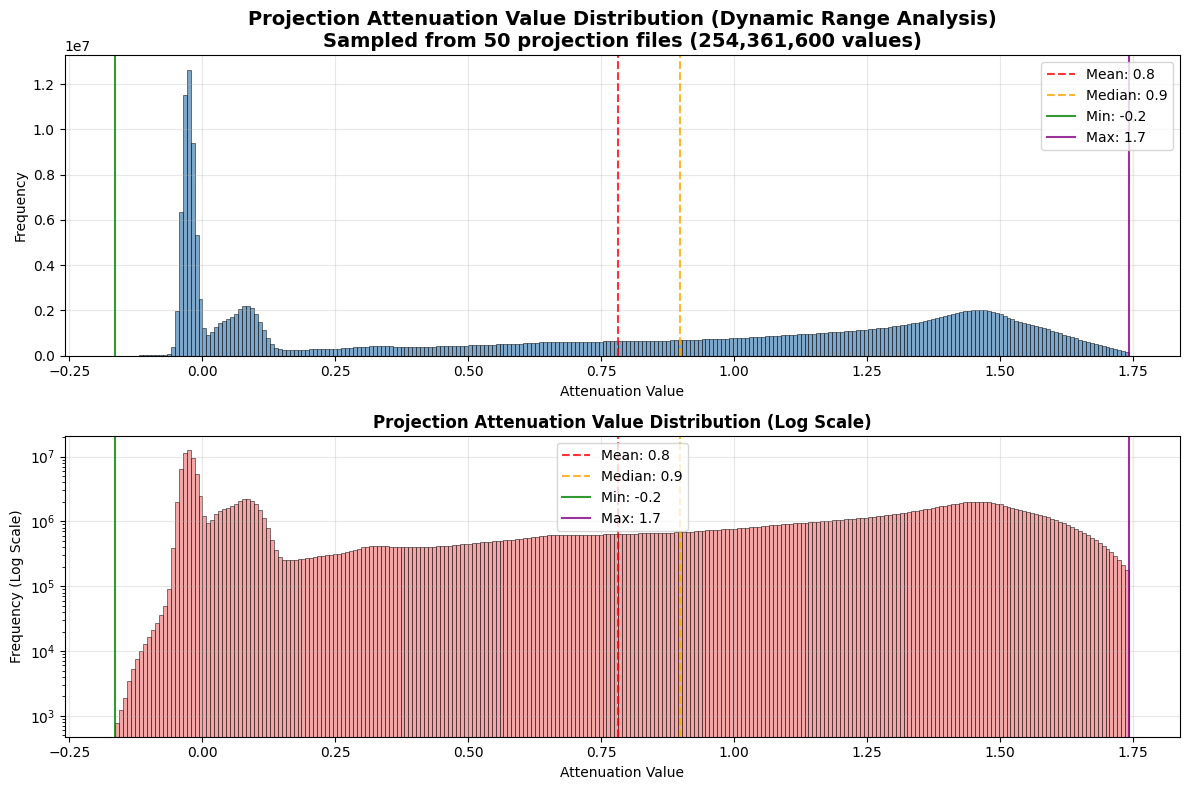


📊 Projection Attenuation Statistics:
   Values analyzed: 254,361,600
   Mean: 0.7824
   Median: 0.8979
   Std deviation: 0.6135
   Min: -0.1633
   Max: 1.7431
   Range: 1.9064

   Percentiles:
      1%: -0.0479
      5%: -0.0330
     10%: -0.0255
     25%: 0.0713
     75%: 1.3670
     90%: 1.5234
     95%: 1.5905
     99%: 1.6873

📊 Dynamic Range Analysis (Projections Only):
   Global min: -0.16329748928546906
   Global max: 1.743119478225708
   Range: 1.906416967511177
   Image dimensions: 2560 x 2160
   Fits in 16-bit: False
   Original dtype: uint16

🏗️  Tomographic Structure Used:
   Dark images: 10
   Flat images: 100
   Projection images: 1601

💾 Memory Analysis (Projections Only):
   Total projection files: 1601
   Estimated memory for full projection load: 35.41 GB
   → Streaming approach recommended for sequences > 2GB


In [6]:
# Step 1: Estimate dynamic range from TIFF sequence (Projections Only)
print("🔍 Step 1: Estimating Dynamic Range from Projections")
print("=" * 50)

USE_ATTENUATION_CORRECTION = True

# Parameters for range estimation
SAMPLE_RATIO = 1.0  # Sample 100% of projection files for range estimation (set to 0.05 for 5% sampling)
MIN_SAMPLES = 10     # Minimum projection files to sample
MAX_SAMPLES = 50  # Maximum projection files to sample

# Histogram parameters
CREATE_HISTOGRAM = True    # Whether to create histogram visualization
HIST_BINS = 256           # Number of bins for histogram
MAX_PIXELS_FOR_HIST = 500000000000  # Maximum pixels for histogram (controls memory usage)

print(f"📊 Configuration:")
print(f"   Sample ratio: {SAMPLE_RATIO} ({SAMPLE_RATIO*100:.1f}% of projection files)")
print(f"   Histogram: {'Enabled' if CREATE_HISTOGRAM else 'Disabled'}")
if CREATE_HISTOGRAM:
    print(f"   Histogram bins: {HIST_BINS}")
    print(f"   Max pixels for histogram: {MAX_PIXELS_FOR_HIST:,}")

# Try to load tomography parameters or use defaults
print(f"\n🔧 Loading tomography parameters...")
tomo_params = load_tomography_params(data_path)

# Estimate the dynamic range from projections only
global_min, global_max, height, width, dtype_info, params_used = estimate_tiff_dynamic_range_tomography(
    tiff_files, 
    params=tomo_params,
    sample_ratio=SAMPLE_RATIO,
    min_samples=MIN_SAMPLES, 
    max_samples=MAX_SAMPLES,
    create_histogram=CREATE_HISTOGRAM,
    hist_bins=HIST_BINS,
    max_pixels_for_hist=MAX_PIXELS_FOR_HIST,
    hist_offset=100,  # Start from first projection
    use_attenuation_correction=USE_ATTENUATION_CORRECTION
)

print(f"\n📊 Dynamic Range Analysis (Projections Only):")
print(f"   Global min: {global_min}")
print(f"   Global max: {global_max}")
print(f"   Range: {global_max - global_min}")
print(f"   Image dimensions: {width} x {height}")
print(f"   Fits in 16-bit: {dtype_info['fits_16bit']}")
print(f"   Original dtype: {dtype_info['original_dtype']}")

print(f"\n🏗️  Tomographic Structure Used:")
print(f"   Dark images: {params_used['num_darks']}")
print(f"   Flat images: {params_used['num_flats']}")
print(f"   Projection images: {params_used['num_projections']}")

# Memory estimation for projection sequence only
projection_frames = params_used['num_projections']
estimated_memory_gb = (projection_frames * height * width * 4) / 1e9  # float32
print(f"\n💾 Memory Analysis (Projections Only):")
print(f"   Total projection files: {projection_frames}")
print(f"   Estimated memory for full projection load: {estimated_memory_gb:.2f} GB")
print(f"   → Streaming approach recommended for sequences > 2GB")

In [7]:
# Step 2: Stream Projection TIFF files to HEVC compression
print("\n🎬 Step 2: Streaming HEVC Compression (Projections Only)")
print("=" * 50)

# Parameters for streaming compression
NUM_FRAMES = 50  # Process all projections - set to a number to limit for testing
START_OFFSET = 0   # Projection frame offset to start from  
OUTPUT_DIR = "streaming_output"
QUALITY = 100         # HEVC quality (0-100, higher = better)
FPS = 30            # Output frame rate

print(f"🎯 Compression will process projections only:")
print(f"   Available projections: {params_used['num_projections']}")
print(f"   Frames to process: {'All' if NUM_FRAMES is None else NUM_FRAMES}")
print(f"   Start offset: {START_OFFSET}")

# Stream compress the projection TIFF files only
streamer, processed_frames, output_segments = stream_tiff_projections_to_hevc(
    tiff_files=tiff_files,
    params=params_used,
    output_path=OUTPUT_DIR,
    global_min=global_min,
    global_max=global_max,
    start_offset=START_OFFSET,
    max_frames=NUM_FRAMES,
    fps=FPS,
    quality=QUALITY,
    segment_prefix=f"{data_path.name}_projections",
    force_software=True,
    preset_sw="slow",
    use_attenuation_correction=USE_ATTENUATION_CORRECTION
)

# Get information about the compressed files
file_info = get_compressed_file_info(output_segments)

print(f"\n📁 Compression Results:")
print(f"   Processed projection frames: {processed_frames}")
print(f"   Output segments: {file_info['num_segments']}")
print(f"   Total compressed size: {file_info['total_size_mb']:.2f} MB")

# Calculate compression metrics
if processed_frames > 0:
    # Estimate original size (projections only)
    original_size_mb = (processed_frames * height * width * 2) / 1e6  # uint16 equivalent
    compression_ratio = original_size_mb / file_info['total_size_mb'] if file_info['total_size_mb'] > 0 else 0
    space_savings = (1 - file_info['total_size_mb'] / original_size_mb) * 100 if original_size_mb > 0 else 0
    bits_per_pixel = (file_info['total_size_mb'] * 8e6) / (processed_frames * height * width)
    
    print(f"\n📊 Compression Analysis (Projections Only):")
    print(f"   Estimated original size: {original_size_mb:.2f} MB")
    print(f"   Compression ratio: {compression_ratio:.1f}:1")
    print(f"   Space savings: {space_savings:.1f}%")
    print(f"   Bits per pixel: {bits_per_pixel:.3f}")
    
    # Compare with full dataset
    total_original_size = (len(tiff_files) * height * width * 2) / 1e6
    print(f"\n🔍 Comparison with Full Dataset:")
    print(f"   Full dataset original size: {total_original_size:.2f} MB")
    print(f"   Projections represent: {(processed_frames / len(tiff_files)) * 100:.1f}% of total files")
    print(f"   Projections size: {(original_size_mb / total_original_size) * 100:.1f}% of total data")
    
    # Store these for later use
    compressed_video_path = output_segments[0] if output_segments else None
    print(f"\n✅ Streaming compression completed!")
    print(f"   Main output file: {compressed_video_path}")
else:
    print("❌ No projection frames were processed!")
    compressed_video_path = None


🎬 Step 2: Streaming HEVC Compression (Projections Only)
🎯 Compression will process projections only:
   Available projections: 1601
   Frames to process: 50
   Start offset: 0
🔬 Loading darks and flats for attenuation correction...


Loading darks:   0%|          | 0/10 [00:00<?, ?it/s]

   Dark average range: [73.50, 1674.00]


Loading flats:   0%|          | 0/100 [00:00<?, ?it/s]

   Flat average range: [31456.00, 48802.50]
   Attenuation correction setup complete!
🎬 Streaming compression of projection TIFF files...
   Total projections available: 1601
   Processing mode: Attenuation correction
   Processing 50 projection files...
   Output directory: streaming_output
   Attenuation range: [-0.16329748928546906, 1.743119478225708] (for normalization after log transform)
   Epsilon: 1e-06
   Quality: 100, FPS: 30
   Started segment: file_1_extracted_projections_projections.mov


Processing projection frames (attenuation):   0%|          | 0/50 [00:00<?, ?it/s]

❌ Error during streaming compression: libx265 failed during finalize. stderr:



RuntimeError: libx265 failed during finalize. stderr:


# Compute compression for all folders

In [7]:
# Batch Processing Script for All CT Files Folders (Projections Only)
# Process all folders in ../data/ct_files/ with quality settings, focusing on projections

import os
import time
from pathlib import Path
import pandas as pd
from datetime import datetime

# Configuration
CT_FILES_BASE_PATH = Path('../data/ct_files/')
QUALITY_SETTINGS = [100, 95, 90]  # Quality settings to test
SAMPLE_RATIO = 1.0  # 100% sampling for dynamic range estimation from projections
MIN_SAMPLES = 5     # Minimum projection files to sample
MAX_SAMPLES = 10000    # Maximum projection files to sample
FPS = 30            # Output frame rate
CREATE_HISTOGRAM = False  # Disable histograms for batch processing to save time
FORCE_SOFTWARE_ENCODING = True  # Force software encoding for compatibility
PRESET_SW = "slow"  # Software encoding preset


# Results tracking
batch_results = []

print("🚀 Starting Batch Processing of All CT Files (Projections Only)")
print("=" * 60)
print(f"Base path: {CT_FILES_BASE_PATH.absolute()}")
print(f"Quality settings: {QUALITY_SETTINGS}")
print(f"Sample ratio: {SAMPLE_RATIO} ({SAMPLE_RATIO*100:.1f}% of projections)")
print("")

# Get all subdirectories in ct_files
if not CT_FILES_BASE_PATH.exists():
    print(f"❌ Error: Base path {CT_FILES_BASE_PATH} does not exist!")
else:
    # Get all folders (excluding hidden files like .DS_Store)
    ct_folders = [f for f in CT_FILES_BASE_PATH.iterdir() if f.is_dir()]
    ct_folders = sorted(ct_folders)
    
    print(f"📁 Found {len(ct_folders)} folders to process:")
    for i, folder in enumerate(ct_folders, 1):
        print(f"   {i:2d}. {folder.name}")
    
    print(f"\n🎯 Total processing tasks: {len(ct_folders)} folders × {len(QUALITY_SETTINGS)} qualities = {len(ct_folders) * len(QUALITY_SETTINGS)} tasks")
    print("")
    
    # Process each folder
    overall_start_time = time.time()

    for folder_idx, data_path in tqdm(enumerate(ct_folders, 1)):
        folder_name = data_path.name
        print(f"\n📂 [{folder_idx}/{len(ct_folders)}] Processing folder: {folder_name}")
        print("-" * 80)
        
        # Check if the folder contains TIFF files
        tiff_files = sorted(list(data_path.glob('*.tif')) + list(data_path.glob('*.tiff')))
        
        if len(tiff_files) == 0:
            print(f"   ⚠️  No TIFF files found in {folder_name}, skipping...")
            continue
            
        print(f"   Found {len(tiff_files)} TIFF files")
        
        # Set up tomography parameters for this folder
        folder_tomo_params = load_tomography_params(data_path)
        folder_tomo_params['num_projections'] = len(tiff_files) - folder_tomo_params['num_darks'] - folder_tomo_params['num_flats']
        
        if folder_tomo_params['num_projections'] <= 0:
            print(f"   ⚠️  Invalid tomography structure for {folder_name} - not enough files for projections, skipping...")
            continue
            
        print(f"   📊 Tomography structure: {folder_tomo_params['num_darks']} darks + {folder_tomo_params['num_flats']} flats + {folder_tomo_params['num_projections']} projections")
        
        # Estimate dynamic range from projections only
        print(f"   🔍 Estimating dynamic range from projections...")
        try:
            start_time = time.time()
            global_min, global_max, height, width, dtype_info, params_used = estimate_tiff_dynamic_range_tomography(
                tiff_files, 
                params=folder_tomo_params,
                sample_ratio=SAMPLE_RATIO,
                min_samples=MIN_SAMPLES, 
                max_samples=MAX_SAMPLES,
                create_histogram=CREATE_HISTOGRAM,  # Disable for batch processing
                hist_bins=64,  # Reduced bins
                max_pixels_for_hist=100000,  # Reduced for speed
                hist_offset=0,
            )
            estimation_time = time.time() - start_time
            
            print(f"   ✅ Projection dynamic range: [{global_min}, {global_max}] (took {estimation_time:.1f}s)")
            print(f"   📐 Dimensions: {width} x {height}")
            print(f"   🎯 Will process {params_used['num_projections']} projection frames")
            
        except Exception as e:
            print(f"   ❌ Error estimating dynamic range for {folder_name}: {e}")
            continue

        # Process with each quality setting
        for quality_idx, quality in enumerate(QUALITY_SETTINGS, 1):
            print(f"\n   🎬 [{quality_idx}/{len(QUALITY_SETTINGS)}] Processing projections with quality {quality}...")
            
            # Create unique output directory for this folder and quality
            output_dir = f"/das/home/barbaf_l/p22274/compression_paper/streaming_output/{folder_name}_q{quality}"
            try:
                start_time = time.time()
                
                # Stream compress the projection TIFF files only
                streamer, processed_frames, output_segments = stream_tiff_projections_to_hevc(
                    tiff_files=tiff_files,
                    params=params_used,
                    output_path=output_dir,
                    global_min=global_min,
                    global_max=global_max,
                    start_offset=0,
                    max_frames=None,  # Process all projections
                    fps=FPS,
                    quality=quality,
                    segment_prefix=f"{folder_name}_q{quality}",
                    force_software=FORCE_SOFTWARE_ENCODING,
                    preset_sw=PRESET_SW
                )
                
                compression_time = time.time() - start_time
                
                # Get file information
                file_info = get_compressed_file_info(output_segments)
                
                # Calculate metrics (for projections only)
                original_size_mb = (processed_frames * height * width * 2) / 1e6  # uint16 equivalent
                compression_ratio = original_size_mb / file_info['total_size_mb'] if file_info['total_size_mb'] > 0 else 0
                space_savings = (1 - file_info['total_size_mb'] / original_size_mb) * 100 if original_size_mb > 0 else 0
                bits_per_pixel = (file_info['total_size_mb'] * 8e6) / (processed_frames * height * width) if processed_frames > 0 else 0
                fps_actual = processed_frames / compression_time if compression_time > 0 else 0
                
                # Calculate full dataset comparison
                total_original_size_mb = (len(tiff_files) * height * width * 2) / 1e6
                projection_data_fraction = original_size_mb / total_original_size_mb if total_original_size_mb > 0 else 0
                
                # Store results
                result = {
                    'folder_name': folder_name,
                    'quality': quality,
                    'data_type': 'projections_only',
                    'num_tiff_files_total': len(tiff_files),
                    'num_darks': params_used['num_darks'],
                    'num_flats': params_used['num_flats'],
                    'num_projections': params_used['num_projections'],
                    'processed_frames': processed_frames,
                    'width': width,
                    'height': height,
                    'global_min': global_min,
                    'global_max': global_max,
                    'dynamic_range': global_max - global_min,
                    'projection_original_size_mb': original_size_mb,
                    'total_original_size_mb': total_original_size_mb,
                    'projection_data_fraction': projection_data_fraction,
                    'compressed_size_mb': file_info['total_size_mb'],
                    'compression_ratio': compression_ratio,
                    'space_savings_pct': space_savings,
                    'bits_per_pixel': bits_per_pixel,
                    'compression_time_s': compression_time,
                    'fps_processing': fps_actual,
                    'output_dir': output_dir,
                    'num_segments': file_info['num_segments'],
                    'timestamp': datetime.now().isoformat(),
                    'preset_sw': PRESET_SW,
                    'force_software_encoding': FORCE_SOFTWARE_ENCODING
                }
                batch_results.append(result)
                
                print(f"   ✅ Quality {quality} completed:")
                print(f"      📊 Projection frames: {processed_frames}, Size: {file_info['total_size_mb']:.1f} MB")
                print(f"      🗜️  Compression: {compression_ratio:.1f}:1, Space savings: {space_savings:.1f}%")
                print(f"      📈 Projection data: {projection_data_fraction*100:.1f}% of total dataset")
                print(f"      ⏱️  Time: {compression_time:.1f}s, Speed: {fps_actual:.1f} fps")
                
            except Exception as e:
                print(f"   ❌ Error processing {folder_name} projections with quality {quality}: {e}")
                # Store error result
                error_result = {
                    'folder_name': folder_name,
                    'quality': quality,
                    'data_type': 'projections_only',
                    'error': str(e),
                    'timestamp': datetime.now().isoformat()
                }
                batch_results.append(error_result)
                continue
    
    # Calculate overall timing
    total_time = time.time() - overall_start_time
    successful_tasks = len([r for r in batch_results if 'error' not in r])
    failed_tasks = len([r for r in batch_results if 'error' in r])
    
    print(f"\n🏁 Batch Processing Complete!")
    print("=" * 60)
    print(f"📊 Summary:")
    print(f"   Total folders processed: {len(ct_folders)}")
    print(f"   Successful tasks: {successful_tasks}")
    print(f"   Failed tasks: {failed_tasks}")
    print(f"   Total time: {total_time/60:.1f} minutes")
    print(f"   Average time per task: {total_time/len(batch_results):.1f} seconds")
    
    if successful_tasks > 0:
        # Calculate summary statistics for projections
        success_results = [r for r in batch_results if 'error' not in r]
        total_projection_frames = sum(r['processed_frames'] for r in success_results)
        total_original_projections_mb = sum(r['projection_original_size_mb'] for r in success_results)
        total_compressed_mb = sum(r['compressed_size_mb'] for r in success_results)
        overall_compression_ratio = total_original_projections_mb / total_compressed_mb if total_compressed_mb > 0 else 0
        
        print(f"\n� Overall Projection Compression Summary:")
        print(f"   Total projection frames processed: {total_projection_frames:,}")
        print(f"   Total original projection data: {total_original_projections_mb:.1f} MB")
        print(f"   Total compressed data: {total_compressed_mb:.1f} MB")
        print(f"   Overall compression ratio: {overall_compression_ratio:.1f}:1")
        print(f"   Overall space savings: {(1 - total_compressed_mb/total_original_projections_mb)*100:.1f}%")
    
    print(f"\n�💾 Results stored in 'batch_results' variable ({len(batch_results)} entries)")
    print("   Results focus on projection data only (darks and flats excluded from compression)")

🚀 Starting Batch Processing of All CT Files (Projections Only)
Base path: /das/home/barbaf_l/sdate/notebooks/../data/ct_files
Quality settings: [100, 95, 90]
Sample ratio: 1.0 (100.0% of projections)

❌ Error: Base path ../data/ct_files does not exist!


In [8]:
# Comprehensive Results Analysis and Summary for Projection Compression
# Analyze and visualize the batch processing results (projections only)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Generating Comprehensive Results Analysis (Projections Only)")
print("=" * 60)

if 'batch_results' in locals() and batch_results:
    # Convert results to DataFrame for easier analysis
    df_results = pd.DataFrame([r for r in batch_results if 'error' not in r])
    df_errors = pd.DataFrame([r for r in batch_results if 'error' in r])
    
    print(f"📈 Analysis of {len(df_results)} successful projection processing tasks:")
    print("")
    
    # 1. Basic Statistics
    print("1. 📊 BASIC STATISTICS (PROJECTIONS ONLY)")
    print("-" * 40)
    
    if not df_results.empty:
        print(f"   Folders processed: {df_results['folder_name'].nunique()}")
        print(f"   Quality settings: {sorted(df_results['quality'].unique())}")
        print(f"   Total projection frames processed: {df_results['processed_frames'].sum():,}")
        print(f"   Total original projection data: {df_results['projection_original_size_mb'].sum():.1f} MB")
        print(f"   Total compressed projection data: {df_results['compressed_size_mb'].sum():.1f} MB")
        print(f"   Overall projection compression ratio: {df_results['projection_original_size_mb'].sum() / df_results['compressed_size_mb'].sum():.1f}:1")
        print(f"   Overall projection space savings: {(1 - df_results['compressed_size_mb'].sum() / df_results['projection_original_size_mb'].sum()) * 100:.1f}%")
        
        # Full dataset comparison
        total_full_data = df_results['total_original_size_mb'].sum()
        avg_projection_fraction = df_results['projection_data_fraction'].mean()
        print(f"\n   📊 Dataset Composition:")
        print(f"   Total full dataset size: {total_full_data:.1f} MB")
        print(f"   Average projection fraction: {avg_projection_fraction*100:.1f}% of total data")
        print(f"   Average darks per folder: {df_results['num_darks'].mean():.1f}")
        print(f"   Average flats per folder: {df_results['num_flats'].mean():.1f}")
        print(f"   Average projections per folder: {df_results['num_projections'].mean():.1f}")
        print("")
        
        # 2. Quality Comparison
        print("2. 🎛️  QUALITY SETTINGS COMPARISON (PROJECTIONS)")
        print("-" * 40)
        
        for quality in sorted(df_results['quality'].unique()):
            subset = df_results[df_results['quality'] == quality]
            print(f"   Quality {quality}:")
            print(f"      Compression ratio: {subset['compression_ratio'].mean():.1f}:1 (±{subset['compression_ratio'].std():.1f})")
            print(f"      Space savings: {subset['space_savings_pct'].mean():.1f}% (±{subset['space_savings_pct'].std():.1f}%)")
            print(f"      Bits per pixel: {subset['bits_per_pixel'].mean():.3f} (±{subset['bits_per_pixel'].std():.3f})")
            print(f"      Processing speed: {subset['fps_processing'].mean():.1f} fps (±{subset['fps_processing'].std():.1f})")
            print(f"      Total compressed size: {subset['compressed_size_mb'].sum():.1f} MB")
            print("")
        
        # 3. Folder-wise Analysis
        print("3. 📁 FOLDER-WISE ANALYSIS (PROJECTIONS)")
        print("-" * 40)
        folder_summary = df_results.groupby('folder_name').agg({
            'num_tiff_files_total': 'first',
            'num_projections': 'first',
            'processed_frames': 'first',
            'width': 'first',
            'height': 'first',
            'dynamic_range': 'first',
            'projection_data_fraction': 'first',
            'compression_ratio': 'mean',
            'space_savings_pct': 'mean',
            'compression_time_s': 'mean'
        }).round(2)
        
        print(f"   {'Folder':<35} {'Total':<7} {'Proj':<6} {'Size':<12} {'Range':<8} {'Proj%':<6} {'Ratio':<6}")
        print(f"   {'-'*35} {'-'*6} {'-'*5} {'-'*11} {'-'*7} {'-'*5} {'-'*5}")
        
        for folder_name, row in folder_summary.iterrows():
            folder_display = folder_name[:32] + "..." if len(folder_name) > 35 else folder_name
            size_str = f"{row['width']}x{row['height']}"
            proj_pct = f"{row['projection_data_fraction']*100:.0f}%"
            print(f"   {folder_display:<35} {row['num_tiff_files_total']:<7.0f} {row['num_projections']:<6.0f} {size_str:<12} {row['dynamic_range']:<8.0f} {proj_pct:<6} {row['compression_ratio']:<6.1f}")
        
        print("")
        
        # 4. Visualization
        print("4. 📈 GENERATING VISUALIZATIONS")
        print("-" * 40)
        
        # Set up the plotting style
        plt.style.use('default')
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('TIFF Projection Compression Results', fontsize=16, fontweight='bold')
        
        # Plot 1: Compression Ratio by Quality
        ax1 = axes[0, 0]
        quality_data = [df_results[df_results['quality'] == q]['compression_ratio'].values for q in sorted(df_results['quality'].unique())]
        ax1.boxplot(quality_data, tick_labels=[f'Q{q}' for q in sorted(df_results['quality'].unique())])
        ax1.set_title('Projection Compression Ratio by Quality')
        ax1.set_ylabel('Compression Ratio')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Space Savings by Quality
        ax2 = axes[0, 1]
        space_data = [df_results[df_results['quality'] == q]['space_savings_pct'].values for q in sorted(df_results['quality'].unique())]
        ax2.boxplot(space_data, tick_labels=[f'Q{q}' for q in sorted(df_results['quality'].unique())])
        ax2.set_title('Projection Space Savings by Quality')
        ax2.set_ylabel('Space Savings (%)')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Bits per Pixel by Quality
        ax3 = axes[0, 2]
        bpp_data = [df_results[df_results['quality'] == q]['bits_per_pixel'].values for q in sorted(df_results['quality'].unique())]
        ax3.boxplot(bpp_data, tick_labels=[f'Q{q}' for q in sorted(df_results['quality'].unique())])
        ax3.set_title('Projection Bits per Pixel by Quality')
        ax3.set_ylabel('Bits per Pixel')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Processing Speed by Quality
        ax4 = axes[1, 0]
        fps_data = [df_results[df_results['quality'] == q]['fps_processing'].values for q in sorted(df_results['quality'].unique())]
        ax4.boxplot(fps_data, tick_labels=[f'Q{q}' for q in sorted(df_results['quality'].unique())])
        ax4.set_title('Projection Processing Speed by Quality')
        ax4.set_ylabel('Processing Speed (fps)')
        ax4.grid(True, alpha=0.3)
        
        # Plot 5: Projection Data Fraction vs Compression Ratio
        ax5 = axes[1, 1]
        scatter = ax5.scatter(df_results['projection_data_fraction']*100, df_results['compression_ratio'], 
                             c=df_results['quality'], cmap='viridis', alpha=0.7)
        ax5.set_xlabel('Projection Data Fraction (%)')
        ax5.set_ylabel('Compression Ratio')
        ax5.set_title('Compression vs Projection Fraction')
        ax5.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax5, label='Quality')
        
        # Plot 6: Number of Projections Distribution
        ax6 = axes[1, 2]
        ax6.hist(df_results['num_projections'].unique(), bins=15, alpha=0.7, edgecolor='black')
        ax6.set_xlabel('Number of Projections')
        ax6.set_ylabel('Number of Datasets')
        ax6.set_title('Distribution of Projection Counts')
        ax6.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 5. Tomographic Structure Analysis
        print("5. 🏗️  TOMOGRAPHIC STRUCTURE ANALYSIS")
        print("-" * 40)
        
        # Create tomographic structure summary
        tomo_summary = df_results.groupby('folder_name').agg({
            'num_tiff_files_total': 'first',
            'num_darks': 'first', 
            'num_flats': 'first',
            'num_projections': 'first',
            'projection_data_fraction': 'first'
        }).round(3)
        
        print("   Tomographic Composition Analysis:")
        print(f"   Average darks per scan: {df_results['num_darks'].mean():.1f} ± {df_results['num_darks'].std():.1f}")
        print(f"   Average flats per scan: {df_results['num_flats'].mean():.1f} ± {df_results['num_flats'].std():.1f}")
        print(f"   Average projections per scan: {df_results['num_projections'].mean():.1f} ± {df_results['num_projections'].std():.1f}")
        print(f"   Average projection data fraction: {df_results['projection_data_fraction'].mean()*100:.1f}% ± {df_results['projection_data_fraction'].std()*100:.1f}%")
        print("")
        
        # 6. Performance Summary Table
        print("6. 📋 DETAILED PROJECTION PERFORMANCE TABLE")
        print("-" * 40)
        
        # Create a detailed summary table
        if len(df_results['quality'].unique()) > 1:
            summary_table = df_results.pivot_table(
                index='folder_name',
                columns='quality',
                values=['compression_ratio', 'space_savings_pct', 'bits_per_pixel', 'compressed_size_mb'],
                aggfunc='first'
            ).round(2)
            
            print("   Projection Compression Ratios by Folder and Quality:")
            print(summary_table['compression_ratio'].to_string())
            print("")
            
            print("   Projection Compressed File Sizes (MB) by Folder and Quality:")
            print(summary_table['compressed_size_mb'].to_string())
        else:
            # Single quality case
            print("   Single Quality Results:")
            single_q_summary = df_results[['folder_name', 'compression_ratio', 'compressed_size_mb', 'bits_per_pixel']].set_index('folder_name')
            print(single_q_summary.to_string())
        
        print("")
        
        # 7. Export Results
        print("7. 💾 EXPORTING PROJECTION RESULTS")
        print("-" * 40)
        
        # Save detailed results to CSV
        output_file = f'/das/home/barbaf_l/p22274/compression_paper/streaming_output/projection_batch_processing_results_{QUALITY_SETTINGS}.csv'
        os.makedirs('/das/home/barbaf_l/p22274/compression_paper/streaming_output', exist_ok=True)
        df_results.to_csv(output_file, index=False)
        print(f"   ✅ Detailed projection results saved to: {output_file}")
        
        # Save summary statistics
        summary_file = f'/das/home/barbaf_l/p22274/compression_paper/streaming_output/projection_batch_processing_summary_{QUALITY_SETTINGS}.txt'
        with open(summary_file, 'w') as f:
            f.write("TIFF Projection Compression Summary\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            f.write("PROJECTION-ONLY COMPRESSION RESULTS\n")
            f.write("-" * 35 + "\n")
            f.write(f"Folders processed: {df_results['folder_name'].nunique()}\n")
            f.write(f"Quality settings: {sorted(df_results['quality'].unique())}\n")
            f.write(f"Total projection frames: {df_results['processed_frames'].sum():,}\n")
            f.write(f"Total original projection data: {df_results['projection_original_size_mb'].sum():.1f} MB\n")
            f.write(f"Total compressed projection data: {df_results['compressed_size_mb'].sum():.1f} MB\n")
            f.write(f"Overall projection compression ratio: {df_results['projection_original_size_mb'].sum() / df_results['compressed_size_mb'].sum():.1f}:1\n")
            f.write(f"Overall projection space savings: {(1 - df_results['compressed_size_mb'].sum() / df_results['projection_original_size_mb'].sum()) * 100:.1f}%\n\n")
            f.write("TOMOGRAPHIC STRUCTURE\n")
            f.write("-" * 20 + "\n")
            f.write(f"Average darks per scan: {df_results['num_darks'].mean():.1f}\n")
            f.write(f"Average flats per scan: {df_results['num_flats'].mean():.1f}\n")
            f.write(f"Average projections per scan: {df_results['num_projections'].mean():.1f}\n")
            f.write(f"Average projection data fraction: {df_results['projection_data_fraction'].mean()*100:.1f}%\n")
        
        print(f"   ✅ Summary saved to: {summary_file}")
        
        if not df_errors.empty:
            error_file = '/das/home/barbaf_l/p22274/compression_paper/streaming_output/projection_batch_processing_errors.csv'
            df_errors.to_csv(error_file, index=False)
            print(f"   ⚠️  Errors logged to: {error_file}")
    
    else:
        print("❌ No successful results to analyze!")
        
    if not df_errors.empty:
        print(f"\n⚠️  {len(df_errors)} tasks failed:")
        for _, error in df_errors.iterrows():
            print(f"   - {error['folder_name']} (Q{error['quality']}): {error['error']}")

else:
    print("❌ No batch_results found! Please run the batch processing script first.")

print(f"\n✅ Projection-focused analysis complete!")
print("🔍 Note: This analysis focuses on projection data only - darks and flats were excluded from compression")

ModuleNotFoundError: No module named 'seaborn'